Downloading...
From (original): https://drive.google.com/uc?id=133E0TDrfIjnhwRoGTw9OEozwBXUL38D8
From (redirected): https://drive.google.com/uc?id=133E0TDrfIjnhwRoGTw9OEozwBXUL38D8&confirm=t&uuid=d9f93d60-2522-4796-bc23-51d396b4d4b9
To: /content/downloaded_file.csv
100%|██████████| 480M/480M [00:07<00:00, 67.0MB/s]


   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0             0.0        0  
1  M2044282225             0.0             0.0        0  
2   C553264065             0.0             0.0        1  
3    C38997010         21182.0             0.0        1  
4  M1230701703             0.0             0.0        0  


In [ ]:
import pandas as pd
import gdown

# File ID and output file name
file_id = "133E0TDrfIjnhwRoGTw9OEozwBXUL38D8"
output = "downloaded_file.csv"
# Construct the download URL
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file using gdown
gdown.download(url, output, quiet=False)

# Load the data into a DataFrame (if it's a CSV)
data = pd.read_csv(output)

# Display the data
print(data.head())

In [ ]:

# Construct the download URL
url = f"https://drive.google.com/uc?id={file_id}"

# Download the file using gdown
gdown.download(url, output, quiet=False)

# Load the data into a DataFrame (if it's a CSV)
data = pd.read_csv(output)

# Display the data
print(data.head())


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import xgboost as xgb
from imblearn.over_sampling import SMOTE


In [3]:
df = pd.read_csv("downloaded_file.csv")


In [4]:
print("Data sample:")
print(df.head())


Data sample:
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  
0  M1979787155             0.0             0.0        0  
1  M2044282225             0.0             0.0        0  
2   C553264065             0.0             0.0        1  
3    C38997010         21182.0             0.0        1  
4  M1230701703             0.0             0.0        0  


In [5]:
print("\nData info:")
print(df.info())



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), object(3)
memory usage: 485.4+ MB
None


In [6]:
print("\nSummary statistics:")
print(df.describe())



Summary statistics:
               step        amount  oldbalanceOrg  newbalanceOrig  \
count  6.362620e+06  6.362620e+06   6.362620e+06    6.362620e+06   
mean   2.433972e+02  1.798619e+05   8.338831e+05    8.551137e+05   
std    1.423320e+02  6.038582e+05   2.888243e+06    2.924049e+06   
min    1.000000e+00  0.000000e+00   0.000000e+00    0.000000e+00   
25%    1.560000e+02  1.338957e+04   0.000000e+00    0.000000e+00   
50%    2.390000e+02  7.487194e+04   1.420800e+04    0.000000e+00   
75%    3.350000e+02  2.087215e+05   1.073152e+05    1.442584e+05   
max    7.430000e+02  9.244552e+07   5.958504e+07    4.958504e+07   

       oldbalanceDest  newbalanceDest       isFraud  
count    6.362620e+06    6.362620e+06  6.362620e+06  
mean     1.100702e+06    1.224996e+06  1.290820e-03  
std      3.399180e+06    3.674129e+06  3.590480e-02  
min      0.000000e+00    0.000000e+00  0.000000e+00  
25%      0.000000e+00    0.000000e+00  0.000000e+00  
50%      1.327057e+05    2.146614e+05  0.0

In [7]:
print("\nFraud distribution:")
print(df['isFraud'].value_counts())
fraud_percentage = df['isFraud'].mean() * 100
print(f"Fraud percentage: {fraud_percentage:.2f}%")



Fraud distribution:
isFraud
0    6354407
1       8213
Name: count, dtype: int64
Fraud percentage: 0.13%


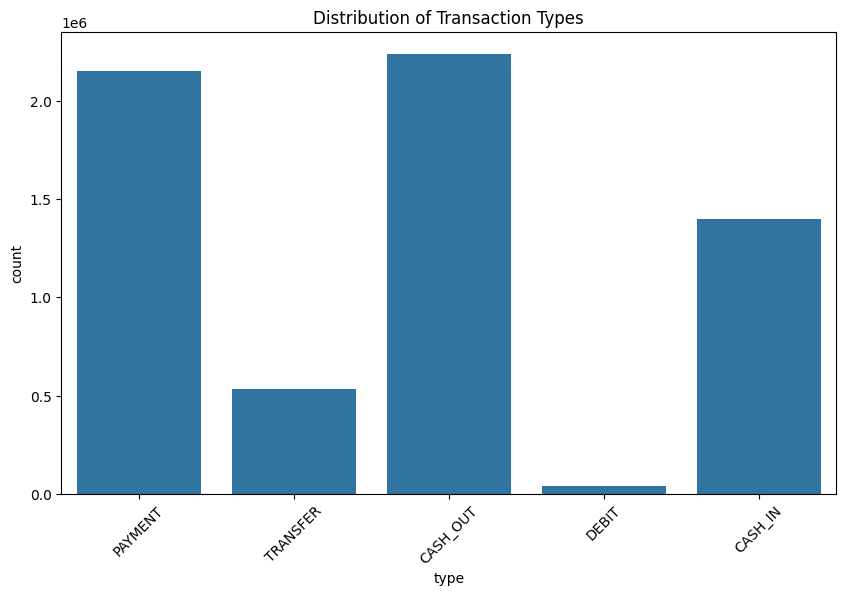

In [8]:
# 2.1 Transaction Types Analysis
plt.figure(figsize=(10, 6))
sns.countplot(x='type', data=df)
plt.title('Distribution of Transaction Types')
plt.xticks(rotation=45)
plt.show()

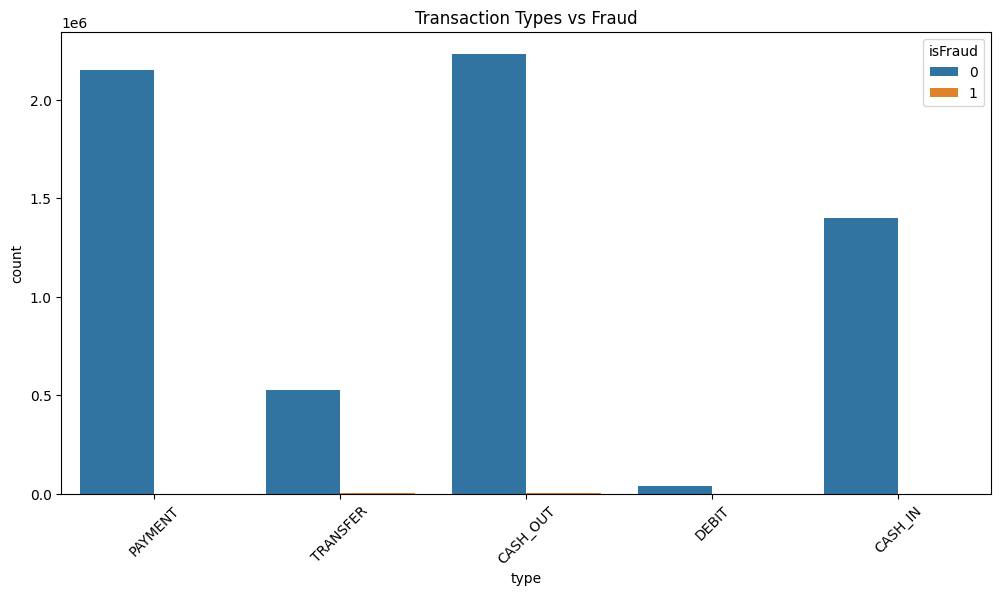

In [9]:
# 2.2 Transaction Types vs Fraud
plt.figure(figsize=(12, 6))
sns.countplot(x='type', hue='isFraud', data=df)
plt.title('Transaction Types vs Fraud')
plt.xticks(rotation=45)
plt.show()

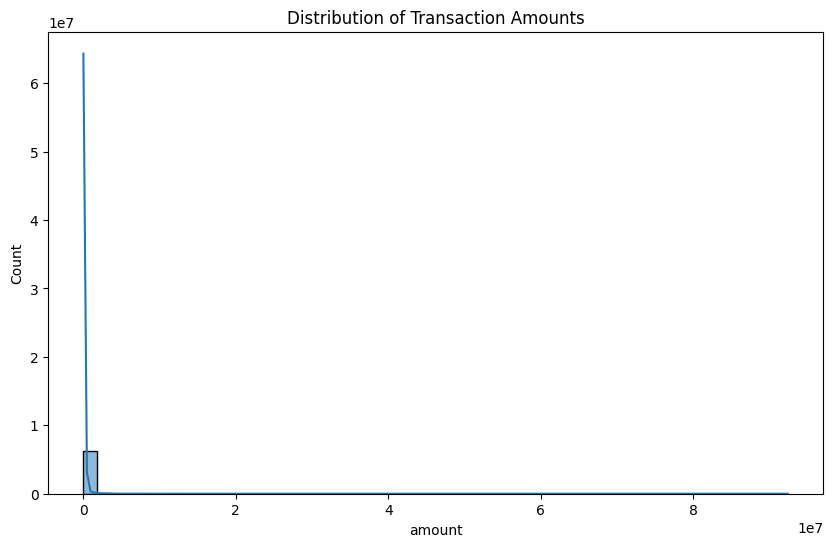

In [10]:
# 2.3 Amount Distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['amount'], bins=50, kde=True)
plt.title('Distribution of Transaction Amounts')
plt.show()

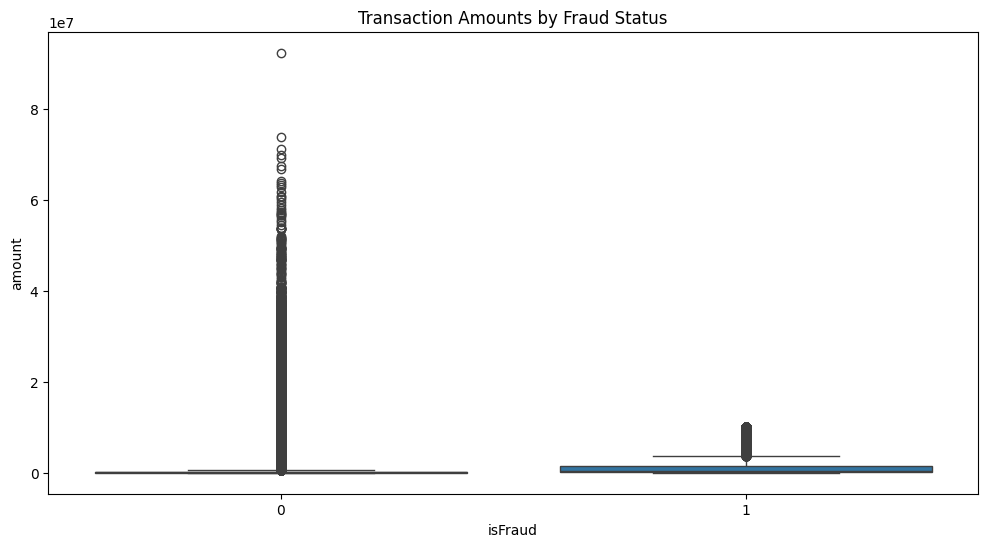

In [11]:
# 2.4 Amount Distribution by Fraud Status
plt.figure(figsize=(12, 6))
sns.boxplot(x='isFraud', y='amount', data=df)
plt.title('Transaction Amounts by Fraud Status')
plt.show()

In [13]:
# 2.5 Feature Engineering: Create new features
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']


In [15]:
# 2.6 Checking if account goes to 0 after transaction
df['isZeroBalanceOrig'] = (df['newbalanceOrig'] == 0).astype(int)
df['isZeroBalanceDest'] = (df['newbalanceDest'] == 0).astype(int)

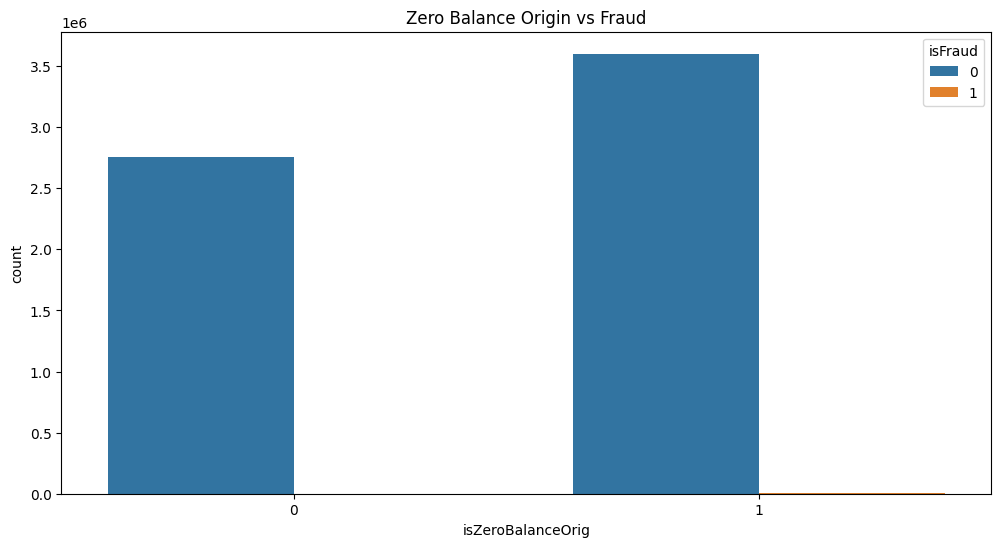

In [16]:
# Visualize these features
plt.figure(figsize=(12, 6))
sns.countplot(x='isZeroBalanceOrig', hue='isFraud', data=df)
plt.title('Zero Balance Origin vs Fraud')
plt.show()

In [17]:
# 3.1 Extract account type from account IDs
df['accountTypeOrig'] = df['nameOrig'].str[0]
df['accountTypeDest'] = df['nameDest'].str[0]


In [21]:
# 3.2 Define features for model
features = [
    'step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
    'oldbalanceDest', 'newbalanceDest', 'errorBalanceOrig',
    'errorBalanceDest', 'isZeroBalanceOrig', 'isZeroBalanceDest'
]

In [22]:
categorical_features = ['type', 'accountTypeOrig', 'accountTypeDest']
target = 'isFraud'

In [23]:
X = df[features + categorical_features]
y = df[target]

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [25]:
# 3.4 Create preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

In [26]:
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features),
        ('cat', categorical_transformer, categorical_features)
    ])

In [28]:
# 4.1 Define models
models = {
    'Random Forest': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', RandomForestClassifier(random_state=42))
    ]),
    'XGBoost': Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'))
    ])
}

In [29]:
# 4.2 Train and evaluate models
results = {}

In [30]:
for name, model in models.items():
    # Apply SMOTE to handle class imbalance (only on training data)
    smote = SMOTE(random_state=42)
    X_train_resampled, y_train_resampled = smote.fit_resample(preprocessor.fit_transform(X_train), y_train)

    # Train model
    model.fit(X_train, y_train)  # Training on original data
    # Alternatively: model.named_steps['classifier'].fit(X_train_resampled, y_train_resampled)

    # Predict
    y_pred = model.predict(X_test)

    # Evaluate
    results[name] = {
        'confusion_matrix': confusion_matrix(y_test, y_pred),
        'classification_report': classification_report(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }

    print(f"\n--- {name} Results ---")
    print(f"Confusion Matrix:\n{results[name]['confusion_matrix']}")
    print(f"Classification Report:\n{results[name]['classification_report']}")
    print(f"AUC-ROC Score: {results[name]['auc_roc']:.4f}")



--- Random Forest Results ---
Confusion Matrix:
[[1270881       0]
 [      4    1639]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       1.00      1.00      1.00      1643

    accuracy                           1.00   1272524
   macro avg       1.00      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC Score: 0.9988


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:27:45] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)



--- XGBoost Results ---
Confusion Matrix:
[[1270851      30]
 [     19    1624]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.98      0.99      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      0.99      0.99   1272524
weighted avg       1.00      1.00      1.00   1272524

AUC-ROC Score: 0.9998


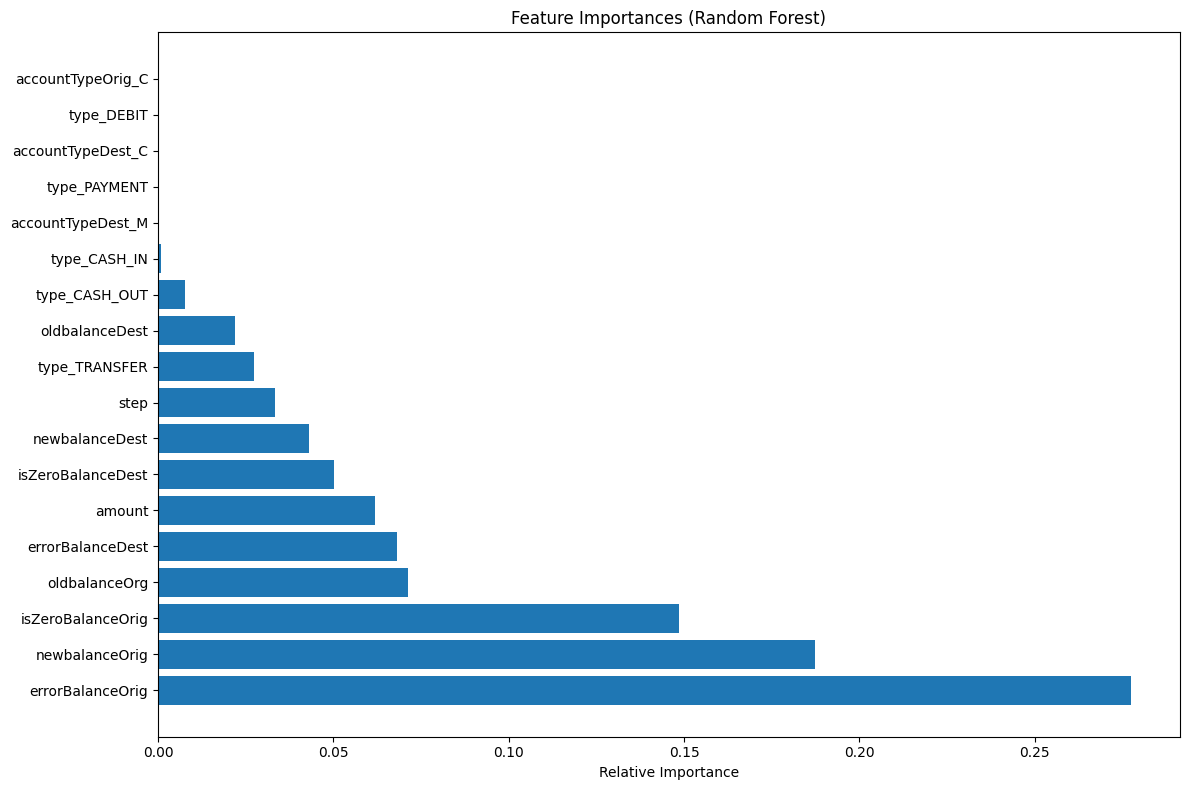

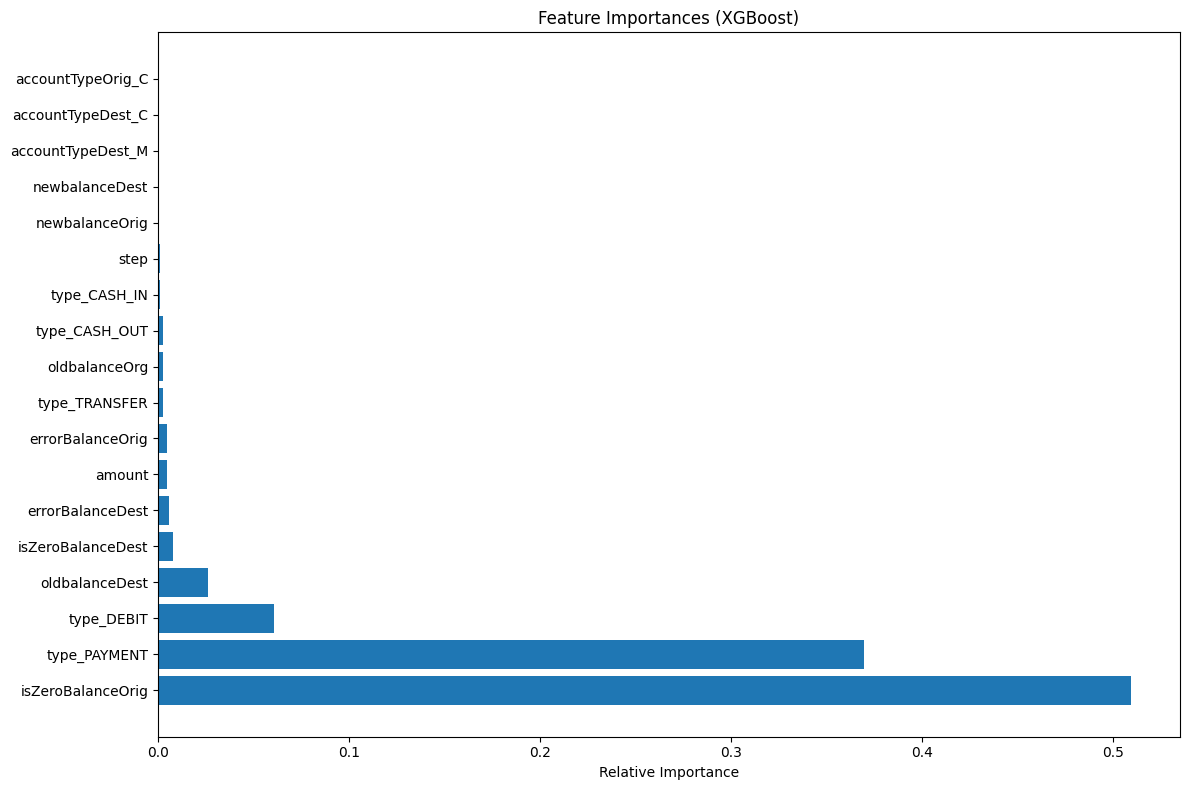

In [31]:
for name, model in models.items():
    if hasattr(model.named_steps['classifier'], 'feature_importances_'):
        # Get feature names after preprocessing
        ohe = model.named_steps['preprocessor'].named_transformers_['cat']['onehot']
        feature_names = features + list(ohe.get_feature_names_out(categorical_features))

        # Get feature importances
        importances = model.named_steps['classifier'].feature_importances_

        # Plot
        plt.figure(figsize=(12, 8))
        indices = np.argsort(importances)[::-1]
        plt.title(f'Feature Importances ({name})')
        plt.barh(range(len(indices)), importances[indices], align='center')
        plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
        plt.xlabel('Relative Importance')
        plt.tight_layout()
        plt.show()


In [37]:
# 6. Predict on new data
def predict_fraud(transaction_data, model):
    """
    Predict if a transaction is fraudulent

    Parameters:
    transaction_data: dict with transaction details
    model: trained model pipeline

    Returns:
    prediction: 0 (not fraud) or 1 (fraud)
    probability: fraud probability
    """
    # Convert to DataFrame
    transaction_df = pd.DataFrame([transaction_data])

    # Extract account types from account IDs
    transaction_df['accountTypeOrig'] = transaction_df['nameOrig'].str[0]
    transaction_df['accountTypeDest'] = transaction_df['nameDest'].str[0]

    # Calculate error balances
    transaction_df['errorBalanceOrig'] = transaction_df['newbalanceOrig'] + transaction_df['amount'] - transaction_df['oldbalanceOrg']
    transaction_df['errorBalanceDest'] = transaction_df['oldbalanceDest'] + transaction_df['amount'] - transaction_df['newbalanceDest']

    # Check if balance goes to 0
    transaction_df['isZeroBalanceOrig'] = (transaction_df['newbalanceOrig'] == 0).astype(int)
    transaction_df['isZeroBalanceDest'] = (transaction_df['newbalanceDest'] == 0).astype(int)

    # Select features
    input_features = transaction_df[features + categorical_features]

    # Make prediction
    prediction = model.predict(input_features)[0]
    probability = model.predict_proba(input_features)[0][1]

    return prediction, probability

In [38]:
# 7. Example usage - predicting fraud for a sample transaction
sample_transaction = {
    'step': 10,
    'type': 'TRANSFER',
    'amount': 200.00,
    'nameOrig': 'C9876543210',
    'oldbalanceOrg': 500.00,
    'newbalanceOrig': 300.00,
    'nameDest': 'M1234567890',
    'oldbalanceDest': 0.00,
    'newbalanceDest': 200.00
}

best_model = models['XGBoost']  # Assuming XGBoost performed better
prediction, probability = predict_fraud(sample_transaction, best_model)

print("\nSample Transaction Fraud Prediction:")
print(f"Transaction details: {sample_transaction}")
print(f"Prediction: {'Fraud' if prediction == 1 else 'Not Fraud'}")
print(f"Fraud probability: {probability:.4f}")


Sample Transaction Fraud Prediction:
Transaction details: {'step': 10, 'type': 'TRANSFER', 'amount': 200.0, 'nameOrig': 'C9876543210', 'oldbalanceOrg': 500.0, 'newbalanceOrig': 300.0, 'nameDest': 'M1234567890', 'oldbalanceDest': 0.0, 'newbalanceDest': 200.0}
Prediction: Not Fraud
Fraud probability: 0.0000


In [39]:
# 8. Predicting on multiple test samples
test_samples = [
    {
        'step': 5,
        'type': 'PAYMENT',
        'amount': 5000.00,
        'nameOrig': 'C1111111111',
        'oldbalanceOrg': 10000.00,
        'newbalanceOrig': 5000.00,
        'nameDest': 'M2222222222',
        'oldbalanceDest': 0.00,
        'newbalanceDest': 0.00
    },
    {
        'step': 6,
        'type': 'TRANSFER',
        'amount': 2000.00,
        'nameOrig': 'C3333333333',
        'oldbalanceOrg': 2000.00,
        'newbalanceOrig': 0.00,  # Account emptied - suspicious
        'nameDest': 'C4444444444',
        'oldbalanceDest': 0.00,
        'newbalanceDest': 2000.00
    },
    {
        'step': 7,
        'type': 'CASH_OUT',
        'amount': 3000.00,
        'nameOrig': 'C5555555555',
        'oldbalanceOrg': 3000.00,
        'newbalanceOrig': 0.00,  # Account emptied - suspicious
        'nameDest': 'C6666666666',
        'oldbalanceDest': 0.00,
        'newbalanceDest': 3000.00
    }
]

In [40]:
import pickle
import joblib
import os

def save_model(model, model_name, directory="models"):
    """
    Save a trained model to disk

    Parameters:
    model: trained model pipeline
    model_name: name to use for the saved model file
    directory: directory to save the model in (default: 'models')

    Returns:
    file_path: path to the saved model file
    """
    # Create the directory if it doesn't exist
    if not os.path.exists(directory):
        os.makedirs(directory)

    # Create the full file path
    file_path = os.path.join(directory, f"{model_name}.pkl")

    # Save the model using joblib (better for large models)
    joblib.dump(model, file_path)

    print(f"Model saved to {file_path}")
    return file_path

def load_model(model_path):
    """
    Load a trained model from disk

    Parameters:
    model_path: path to the saved model file

    Returns:
    model: loaded model pipeline
    """
    # Load the model using joblib
    model = joblib.load(model_path)

    print(f"Model loaded from {model_path}")
    return model

# Example usage:
# Save the best model
model_path = save_model(best_model, "fraud_detection_xgboost")

# Later, you can load the model
# loaded_model = load_model(model_path)
# prediction, probability = predict_fraud(sample_transaction, loaded_model)

Model saved to models/fraud_detection_xgboost.pkl


In [42]:
import pandas as pd
import numpy as np
import joblib
import os

def load_model(model_path):
    """
    Load a trained model from disk

    Parameters:
    model_path: path to the saved model file

    Returns:
    model: loaded model pipeline
    """
    # Load the model using joblib
    model = joblib.load(model_path)

    print(f"Model loaded from {model_path}")
    return model

def engineer_features(df):
    """
    Apply feature engineering to create the expected columns

    Parameters:
    df: DataFrame with raw transaction data

    Returns:
    df: DataFrame with engineered features
    """
    # Create isZeroBalance features
    df['isZeroBalanceOrig'] = (df['oldbalanceOrg'] == 0).astype(int)
    df['isZeroBalanceDest'] = (df['oldbalanceDest'] == 0).astype(int)

    # Create errorBalance features (difference between expected and actual balance)
    df['errorBalanceOrig'] = df['newbalanceOrig'] - (df['oldbalanceOrg'] - df['amount'])
    df['errorBalanceDest'] = df['newbalanceDest'] - (df['oldbalanceDest'] + df['amount'])

    # Create account type features based on the name prefix
    df['accountTypeOrig'] = df['nameOrig'].str[0]
    df['accountTypeDest'] = df['nameDest'].str[0]

    return df

def predict_single_transaction(transaction, model):
    """
    Predict whether a single transaction is fraudulent

    Parameters:
    transaction: dictionary containing transaction details
    model: trained model pipeline

    Returns:
    prediction: 0 (not fraud) or 1 (fraud)
    probability: probability of fraud
    """
    # Convert single transaction to DataFrame
    df = pd.DataFrame([transaction])

    # Apply feature engineering
    df = engineer_features(df)

    # Make prediction
    prediction = model.predict(df)[0]

    # Get probability (if model supports predict_proba)
    try:
        probability = model.predict_proba(df)[0][1]  # Probability of fraud (class 1)
    except:
        probability = None

    # Display results
    print("\nPrediction Results:")
    print("-" * 80)
    print(f"Transaction Type: {transaction['type']}")
    print(f"Amount: ${transaction['amount']:.2f}")
    print(f"Result: {'⚠️ FRAUD DETECTED' if prediction == 1 else '✅ LEGITIMATE'}")

    if probability is not None:
        print(f"Fraud Probability: {probability:.4f} ({probability*100:.2f}%)")

    # Calculate some additional risk indicators
    emptied_account = transaction['oldbalanceOrg'] > 0 and transaction['newbalanceOrig'] == 0
    large_amount = transaction['amount'] > 1000

    if emptied_account:
        print("Risk Factor: Account emptied")
    if large_amount:
        print("Risk Factor: Large transaction amount")

    # Print the engineered features
    print("\nEngineered Features:")
    for col in ['isZeroBalanceOrig', 'isZeroBalanceDest',
                'errorBalanceOrig', 'errorBalanceDest',
                'accountTypeOrig', 'accountTypeDest']:
        print(f"  {col}: {df[col].values[0]}")

    print("-" * 80)

    return prediction, probability

# Path to your saved model - update this to your actual path
model_path = "/content/models/fraud_detection_xgboost.pkl"

# Load the model
loaded_model = load_model(model_path)

# Single transaction sample
sample_transaction = {
    'step': 7,
    'type': 'CASH_OUT',
    'amount': 3000.00,
    'nameOrig': 'C5555555555',
    'oldbalanceOrg': 3000.00,
    'newbalanceOrig': 0.00,  # Account emptied - suspicious
    'nameDest': 'C6666666666',
    'oldbalanceDest': 0.00,
    'newbalanceDest': 3000.00
}

# Make prediction for the single transaction
prediction, probability = predict_single_transaction(sample_transaction, loaded_model)

Model loaded from /content/models/fraud_detection_xgboost.pkl

Prediction Results:
--------------------------------------------------------------------------------
Transaction Type: CASH_OUT
Amount: $3000.00
Result: ✅ LEGITIMATE
Fraud Probability: 0.0000 (0.00%)
Risk Factor: Account emptied
Risk Factor: Large transaction amount

Engineered Features:
  isZeroBalanceOrig: 0
  isZeroBalanceDest: 1
  errorBalanceOrig: 0.0
  errorBalanceDest: 0.0
  accountTypeOrig: C
  accountTypeDest: C
--------------------------------------------------------------------------------
